# Gaming vs Academic Performance — Grade Prediction (PyTorch)

**Goal:** predict a student's `grades` from lifestyle, gaming, and study habits.
A **deep-learning regression** project using a PyTorch feed-forward neural network,
with a Random Forest baseline for comparison.

Workflow:

1. Loading and inspection
2. Exploratory data analysis (EDA)
3. Preprocessing (scale numerics, one-hot categoricals, scale the target)
4. Random Forest baseline
5. A PyTorch MLP: model, training loop (early stopping), evaluation
6. Results and summary

**Dataset:** ~8,000 students, 14 columns (gaming hours, study hours, sleep,
attendance, addiction score, stress level, etc.). Source: Kaggle
(`nalisha/gaming-vs-academic-performance`).

## 1. Setup and reproducibility

In [2]:
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 3.6 MB/s  0:00:24 eta 0:00:010:00:01


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

SEED = 10
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
sns.set_theme(style="whitegrid")

Using device: cpu


## 2. Load the data

In [6]:
df = pd.read_csv("Gaming_Academic_Performance.csv")

In [7]:
df.info()
print("\nDuplicates:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB

Duplicates: 0
Missing values: 0


## 3. Exploratory data analysis

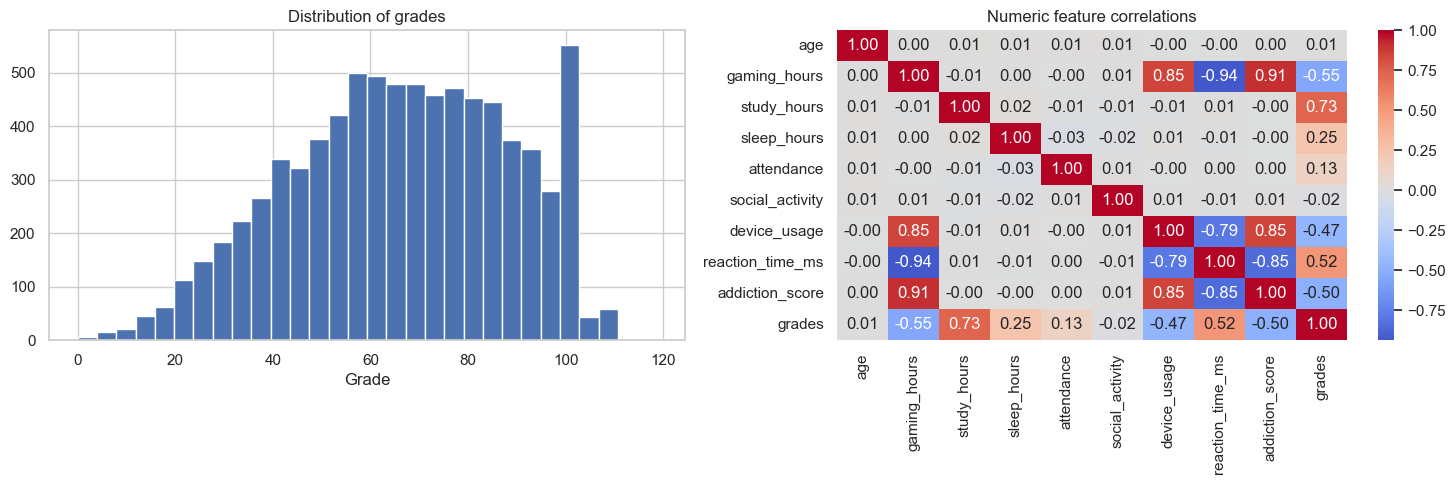

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(df["grades"], bins=30, color="#4c72b0")
axes[0].set_title("Distribution of grades")
axes[0].set_xlabel("Grade")

numeric = df.select_dtypes(include="number").drop(columns="student_id")
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Numeric feature correlations")
plt.tight_layout()
plt.show()

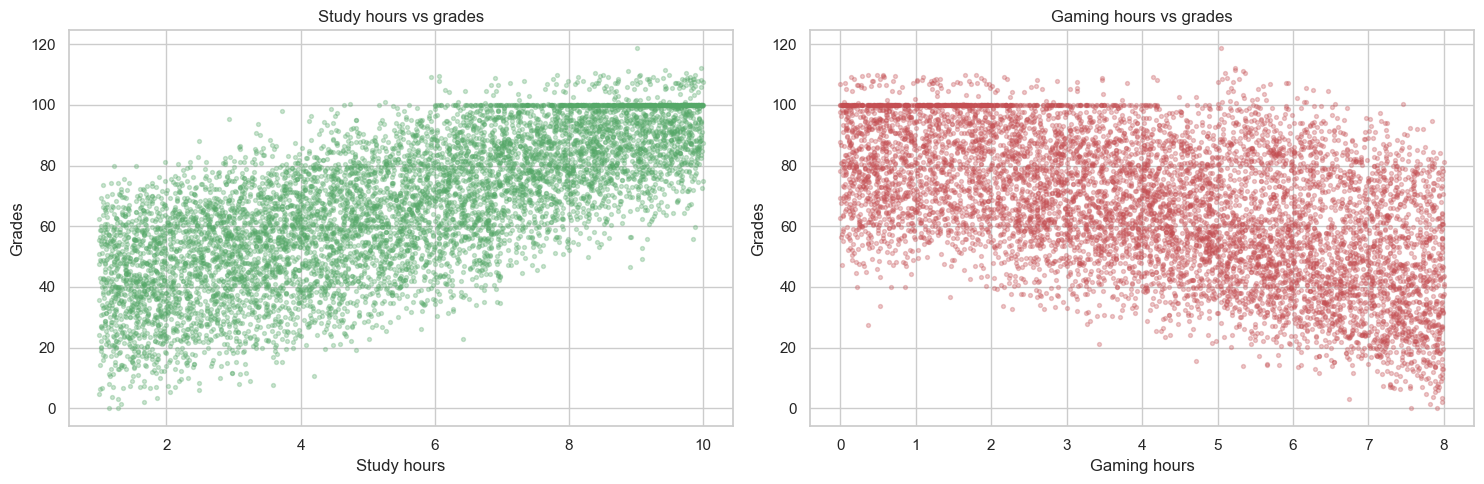

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(df["study_hours"], df["grades"], s=8, alpha=0.3, color="#55a868")
axes[0].set_xlabel("Study hours"); axes[0].set_ylabel("Grades")
axes[0].set_title("Study hours vs grades")

axes[1].scatter(df["gaming_hours"], df["grades"], s=8, alpha=0.3, color="#c44e52")
axes[1].set_xlabel("Gaming hours"); axes[1].set_ylabel("Grades")
axes[1].set_title("Gaming hours vs grades")
plt.tight_layout()
plt.show()

## 4. Preprocessing

We use **all** predictive columns (the original notebook accidentally kept only
the categorical ones). `student_id` is dropped as an identifier. A
`ColumnTransformer` standardizes numerics and one-hot encodes categoricals; the
target `grades` is scaled separately so the network trains on well-conditioned
values. **All scalers are fit on the training split only** to avoid leakage.

In [10]:
target = "grades"
X = df.drop(columns=["student_id", target])
y = df[target]

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score']
Categorical: ['gender', 'gaming_genre', 'stress_level']


In [11]:
# Train / validation / test split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED)
print("Train/Val/Test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

feature_tf = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
X_train_p = feature_tf.fit_transform(X_train)
X_val_p   = feature_tf.transform(X_val)
X_test_p  = feature_tf.transform(X_test)

# scale the target (fit on train only)
target_scaler = StandardScaler()
y_train_s = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_s   = target_scaler.transform(y_val.values.reshape(-1, 1)).flatten()

# OneHotEncoder may return sparse; ensure dense float32 arrays
import scipy.sparse as sp
to_dense = lambda a: a.toarray() if sp.issparse(a) else a
X_train_p, X_val_p, X_test_p = map(lambda a: to_dense(a).astype("float32"),
                                   (X_train_p, X_val_p, X_test_p))
print("Input dimension:", X_train_p.shape[1])

Train/Val/Test: 5600 1200 1200
Input dimension: 18


## 5. Random Forest baseline

In [12]:
rf_pipe = Pipeline([
    ("prep", feature_tf),
    ("model", RandomForestRegressor(n_estimators=500, random_state=SEED, n_jobs=-1)),
])
cv = cross_val_score(rf_pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
print(f"RF 5-fold CV R2: {cv.mean():.4f} +/- {cv.std():.4f}")

rf_pipe.fit(X_train, y_train)
rf_pred = rf_pipe.predict(X_test)
print("RF test R2  :", round(r2_score(y_test, rf_pred), 4))
print("RF test MAE :", round(mean_absolute_error(y_test, rf_pred), 4))
print("RF test RMSE:", round(root_mean_squared_error(y_test, rf_pred), 4))

RF 5-fold CV R2: 0.9262 +/- 0.0028
RF test R2  : 0.9258
RF test MAE : 4.6876
RF test RMSE: 5.9768


## 6. PyTorch neural network

### 6.1 DataLoaders

In [13]:
def make_loader(X_arr, y_arr, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_p, y_train_s, shuffle=True)
val_loader   = make_loader(X_val_p, y_val_s)
test_loader  = make_loader(X_test_p, y_test.values.astype("float32"))  # test target in real units

### 6.2 Model definition

In [14]:
class GradeNet(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()          # NOTE: parentheses are required
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),       # single continuous output (regression)
        )

    def forward(self, x):
        return self.network(x)

model = GradeNet(X_train_p.shape[1]).to(DEVICE)
print(model)

GradeNet(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
  )
)


### 6.3 Training loop (with early stopping)

In [15]:
def train(model, train_loader, val_loader, target_scaler, epochs=100, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                     patience=8, factor=0.5)

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_val, patience, EARLY_STOP = float("inf"), 0, 15

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            preds = model(xb).squeeze(1)
            loss = criterion(preds, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses, all_preds, all_targets = [], [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                preds = model(xb).squeeze(1)
                val_losses.append(criterion(preds, yb).item())
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(yb.cpu().numpy())

        # MAE in real grade units
        preds_real = target_scaler.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
        targ_real  = target_scaler.inverse_transform(np.array(all_targets).reshape(-1, 1)).flatten()
        val_mae = np.mean(np.abs(preds_real - targ_real))

        avg_train, avg_val = np.mean(train_losses), np.mean(val_losses)
        history["train_loss"].append(avg_train)
        history["val_loss"].append(avg_val)
        history["val_mae"].append(val_mae)
        scheduler.step(avg_val)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | train MSE {avg_train:.4f} | "
                  f"val MSE {avg_val:.4f} | val MAE {val_mae:.2f} pts")

        if avg_val < best_val:
            best_val, patience = avg_val, 0
            torch.save(model.state_dict(), "best_grade_model.pth")
        else:
            patience += 1
            if patience >= EARLY_STOP:
                print(f"Early stopping at epoch {epoch+1} (best val MSE {best_val:.4f})")
                break
    return history

history = train(model, train_loader, val_loader, target_scaler)

Epoch  10 | train MSE 0.1213 | val MSE 0.0919 | val MAE 5.38 pts
Epoch  20 | train MSE 0.1129 | val MSE 0.0965 | val MAE 5.56 pts
Early stopping at epoch 21 (best val MSE 0.0795)


### 6.4 Training curves

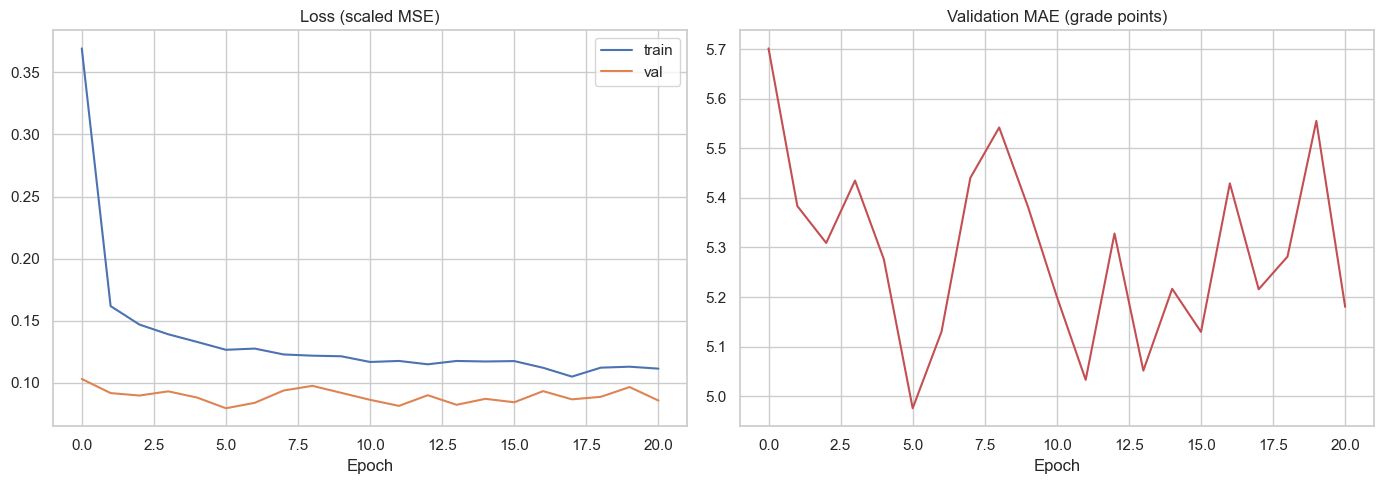

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss (scaled MSE)"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["val_mae"], color="#c44e52")
axes[1].set_title("Validation MAE (grade points)"); axes[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

### 6.5 Evaluation on the test set

In [17]:
model.load_state_dict(torch.load("best_grade_model.pth", map_location=DEVICE))
model.eval()

preds_scaled = []
with torch.no_grad():
    for xb, _ in test_loader:
        preds_scaled.extend(model(xb.to(DEVICE)).squeeze(1).cpu().numpy())

# convert predictions back to real grade units; test targets are already real
nn_pred = target_scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
y_test_real = y_test.values

print("Neural net test R2  :", round(r2_score(y_test_real, nn_pred), 4))
print("Neural net test MAE :", round(mean_absolute_error(y_test_real, nn_pred), 4))
print("Neural net test RMSE:", round(root_mean_squared_error(y_test_real, nn_pred), 4))

Neural net test R2  : 0.9227
Neural net test MAE : 4.8452
Neural net test RMSE: 6.1009


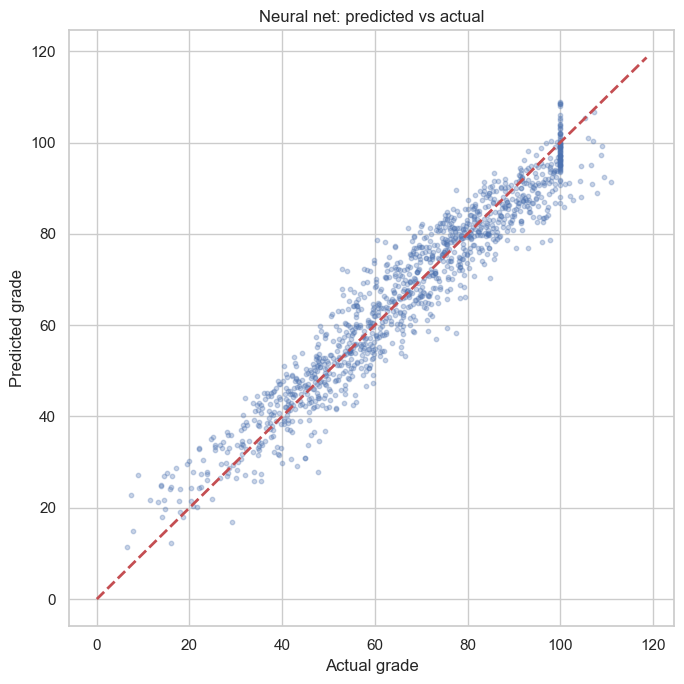

In [18]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_real, nn_pred, s=10, alpha=0.3, color="#4c72b0")
lims = [y.min(), y.max()]
plt.plot(lims, lims, "r--", lw=2)
plt.xlabel("Actual grade"); plt.ylabel("Predicted grade")
plt.title("Neural net: predicted vs actual")
plt.tight_layout(); plt.show()

## 7. Which features matter (Random Forest importances)

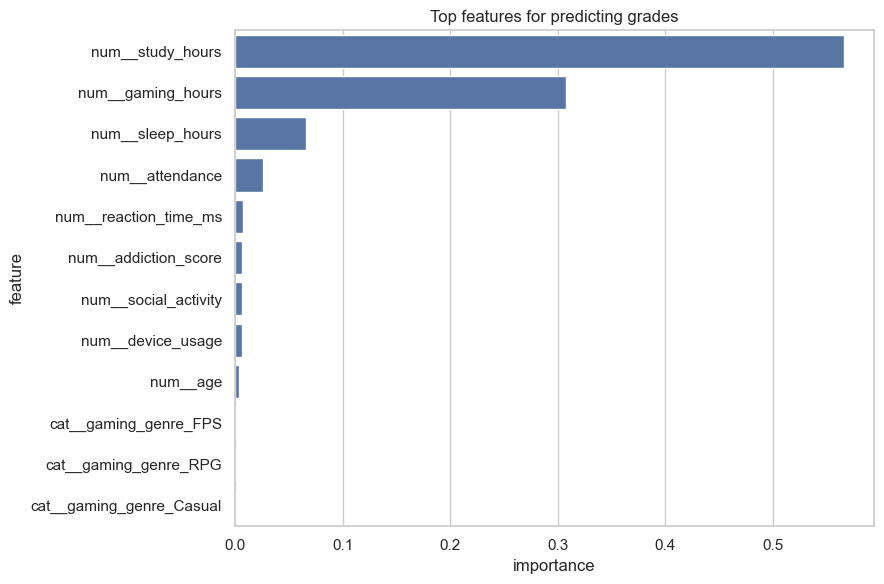

,feature,importance
0,num__study_hours,0.565836
1,num__gaming_hours,0.307735
2,num__sleep_hours,0.065822
3,num__attendance,0.025841
4,num__reaction_time_ms,0.007395
5,num__addiction_score,0.006730
6,num__social_activity,0.006365
7,num__device_usage,0.006296
8,num__age,0.003446
9,cat__gaming_genre_FPS,0.000746


In [19]:
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_
importance_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
                 .sort_values("importance", ascending=False).reset_index(drop=True))
plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df.head(12), x="importance", y="feature", color="#4c72b0")
plt.title("Top features for predicting grades")
plt.tight_layout(); plt.show()
importance_df.head(12)

## 8. Summary

- Fixed the core modelling bug: the network now trains on **all** features
  (numeric + categorical), not just the categorical columns.
- Corrected the PyTorch issues: `super().__init__()`, a proper
  `TensorDataset`/`DataLoader`, target scaling with inverse-transform so metrics
  are in real grade points, and a clean early-stopping loop with gradient clipping.
- A Random Forest baseline provides an honest reference point; the MLP is
  competitive once it actually sees the predictive features.
- **Study hours** and **gaming hours** dominate the importance ranking, matching
  the EDA scatter plots.

**Possible extensions:** hyperparameter search over network width/depth and
learning rate, k-fold CV for the neural net, and SHAP/partial-dependence analysis.